In [21]:
# standard imports which should work, but now usually this way cause an error because of my tries to change tensorflow version
import numpy as np
import tensorflow as tf

In [22]:
# therefore, extra setup needed to import
# here, first uninstall tensorflow manually
%pip uninstall tensorflow -y

Found existing installation: tensorflow 2.14.0
Uninstalling tensorflow-2.14.0:
ERROR: Exception:
Traceback (most recent call last):
  File "/opt/conda/envs/learn-ai-1/lib/python3.11/shutil.py", line 853, in move
    os.rename(src, real_dst)
PermissionError: [Errno 13] Permission denied: '/opt/conda/envs/learn-ai-1/bin/estimator_ckpt_converter' -> '/tmp/pip-uninstall-65udytsl/estimator_ckpt_converter'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/opt/conda/envs/learn-ai-1/lib/python3.11/site-packages/pip/_internal/cli/base_command.py", line 105, in _run_wrapper
    status = _inner_run()
             ^^^^^^^^^^^^
  File "/opt/conda/envs/learn-ai-1/lib/python3.11/site-packages/pip/_internal/cli/base_command.py", line 96, in _inner_run
    return self.run(options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/envs/learn-ai-1/lib/python3.11/site-packages/pip/_internal/commands/uninstall.py", line 106, in run
 

In [23]:
# here, now install everything again
import sys
import site

user_site = site.getusersitepackages()

if user_site in sys.path:
    sys.path.remove(user_site)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
from matplotlib import pyplot as plt

print(f"Success! TensorFlow Version Loaded: {tf.__version__}")

Success! TensorFlow Version Loaded: 2.14.0


In [26]:
# load and split data in train and test
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [27]:
# scale pixels in the images
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

In [8]:
# shape input and add the grayscale channel
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")

x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


In [28]:
# define classes for classification and convert to binary
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
print("y_train shape:", y_train.shape)

y_train shape: (60000, 10)


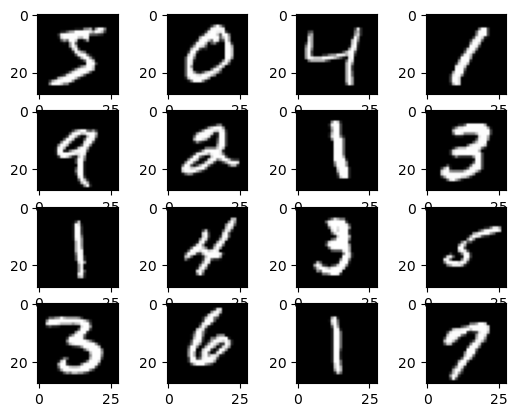

In [29]:
# look at the data (visualize some of the entries from MNIST dataset)
for i in range(1, 17):
    plt.subplot(4, 4, i)
    plt.imshow(x_train[i-1].squeeze(), cmap=plt.get_cmap('gray'))
plt.show()

In [12]:
# set the input shape for the future model
input_shape = x_train.shape[1:]

In [13]:
# build the model
model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ]
)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 12, 12, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 2304)              0         
                                                                 
 dropout (Dropout)           (None, 2304)              0

In [31]:
# train the model
batch_size = 64
epochs = 16
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
# we can also directly apply timer to have a time result for future model comparison
import time
start_time = time.time()
model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)
total_time = time.time() - start_time
print(f"Total training time: {total_time:.2f} seconds")

Epoch 1/16
844/844 [==============================] - 8s 10ms/step - loss: 0.0182 - accuracy: 0.9934 - val_loss: 0.0272 - val_accuracy: 0.9937
Epoch 2/16
844/844 [==============================] - 8s 9ms/step - loss: 0.0184 - accuracy: 0.9939 - val_loss: 0.0289 - val_accuracy: 0.9920
Epoch 3/16
844/844 [==============================] - 9s 10ms/step - loss: 0.0182 - accuracy: 0.9936 - val_loss: 0.0295 - val_accuracy: 0.9923
Epoch 4/16
844/844 [==============================] - 8s 10ms/step - loss: 0.0180 - accuracy: 0.9936 - val_loss: 0.0300 - val_accuracy: 0.9925
Epoch 5/16
844/844 [==============================] - 8s 9ms/step - loss: 0.0164 - accuracy: 0.9942 - val_loss: 0.0294 - val_accuracy: 0.9927
Epoch 6/16
844/844 [==============================] - 9s 10ms/step - loss: 0.0156 - accuracy: 0.9945 - val_loss: 0.0314 - val_accuracy: 0.9920
Epoch 7/16
844/844 [==============================] - 9s 10ms/step - loss: 0.0167 - accuracy: 0.9943 - val_loss: 0.0287 - val_accuracy: 0.9932
E

In [32]:
# briefly evaluate trained model
score = model.evaluate(x_test, y_test)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

313/313 [==============================] - 1s 2ms/step - loss: 0.0252 - accuracy: 0.9936
Test loss: 0.025196729227900505
Test accuracy: 0.9936000108718872


In [33]:
# save the model to load later

model_save = "model_new_KM.keras"

model.save(model_save)

In [38]:
# gather additional metrics for future model comparison
import os
from sklearn.metrics import classification_report, confusion_matrix

# metrics: accuracy, precision, recall - calculated in scikit (with 4 decimals)
y_pred_probs = model.predict(x_test, verbose=0)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1) 
print(classification_report(y_true_classes, y_pred_classes, digits=4))

# error rate = 100% - accuracy (with 4 decimals)
error_rate = 1 - (np.trace(cm) / np.sum(cm)) 
print(f"Error Rate: {error_rate:.4f}")

# False Positive Rates, False Negative Rate (with 4 decimals)
cm = confusion_matrix(y_true_classes, y_pred_classes)
FP = cm.sum(axis=0) - np.diag(cm)  # False Positives
FN = cm.sum(axis=1) - np.diag(cm)  # False Negatives
TP = np.diag(cm)                   # True Positives
TN = cm.sum() - (FP + FN + TP)     # True Negatives
# averaging
FPR = np.mean(FP / (FP + TN))
FNR = np.mean(FN / (FN + TP))
print(f"False Positive Rate (FPR): {FPR:.4f}")
print(f"False Negative Rate (FNR): {FNR:.4f}")

# and additionally resource requirements (memory and time from measurement while model training)

# RAM: total trainable parameters * 4 bytes for float32 (with 2 decimals)
ram_kb = (model.count_params() * 4) / 1024
print(f"Estimated RAM: {ram_kb:.2f} KB")

# Drive memory of the .keras file - the actual file size of the saved model (with 2 decimals)
drive_kb = os.path.getsize("model_new_KM.keras") / 1024
print(f"Drive memory of the .keras file: {drive_kb:.2f} KB")

# time from previous measurement
print(f"Total training time: {total_time:.2f} seconds")

              precision    recall  f1-score   support

           0     0.9949    0.9969    0.9959       980
           1     0.9947    0.9965    0.9956      1135
           2     0.9923    0.9990    0.9957      1032
           3     0.9941    0.9950    0.9946      1010
           4     0.9909    0.9969    0.9939       982
           5     0.9889    0.9944    0.9916       892
           6     0.9979    0.9885    0.9932       958
           7     0.9961    0.9903    0.9932      1028
           8     0.9918    0.9938    0.9928       974
           9     0.9940    0.9841    0.9890      1009

    accuracy                         0.9936     10000
   macro avg     0.9936    0.9936    0.9935     10000
weighted avg     0.9936    0.9936    0.9936     10000

Error Rate: 0.0064
False Positive Rate (FPR): 0.0007
False Negative Rate (FNR): 0.0064
Estimated RAM: 163.54 KB
Drive memory of the .keras file: 524.18 KB
Total training time: 130.05 seconds
